In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── GLOBAL STYLE ──────────────────────────────────────────
plt.rcParams['figure.figsize']  = (12, 6)
plt.rcParams['font.family']     = 'DejaVu Sans'
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False

# Color palette — professional dark orange/red for breach theme
BREACH_COLOR  = "#E63946"
SAFE_COLOR    = "#2A9D8F"
PALETTE       = ["#E63946","#E76F51","#F4A261","#E9C46A","#2A9D8F","#264653","#457B9D"]

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# Load all SQL export CSVs
kpi          = pd.read_csv("../data/kpi_overall.csv")
carrier      = pd.read_csv("../data/breach_by_carrier.csv")
pincode      = pd.read_csv("../data/breach_by_pincode.csv")
day          = pd.read_csv("../data/breach_by_day.csv")
month        = pd.read_csv("../data/breach_by_month.csv")
carrier_city = pd.read_csv("../data/breach_by_carrier_city.csv")
reason       = pd.read_csv("../data/breach_by_reason.csv")
category     = pd.read_csv("../data/breach_by_category.csv")
main_df      = pd.read_csv("../data/logistics_data.csv")

print("✅ All CSVs loaded!")
print(f"\n📊 KPI Snapshot:")
print(f"   Total Orders      : {kpi['total_orders'].values[0]:,}")
print(f"   Total Breaches    : {kpi['total_breaches'].values[0]:,}")
print(f"   Overall Breach %  : {kpi['overall_breach_rate_pct'].values[0]}%")
print(f"   Avg Delivery Days : {kpi['avg_delivery_days'].values[0]}")
print(f"   Total Value       : ₹{kpi['total_value_lakhs'].values[0]:,} Lakhs")

✅ All CSVs loaded!

📊 KPI Snapshot:
   Total Orders      : 50,000
   Total Breaches    : 11,063
   Overall Breach %  : 22.13%
   Avg Delivery Days : 4.27
   Total Value       : ₹5,545.2 Lakhs


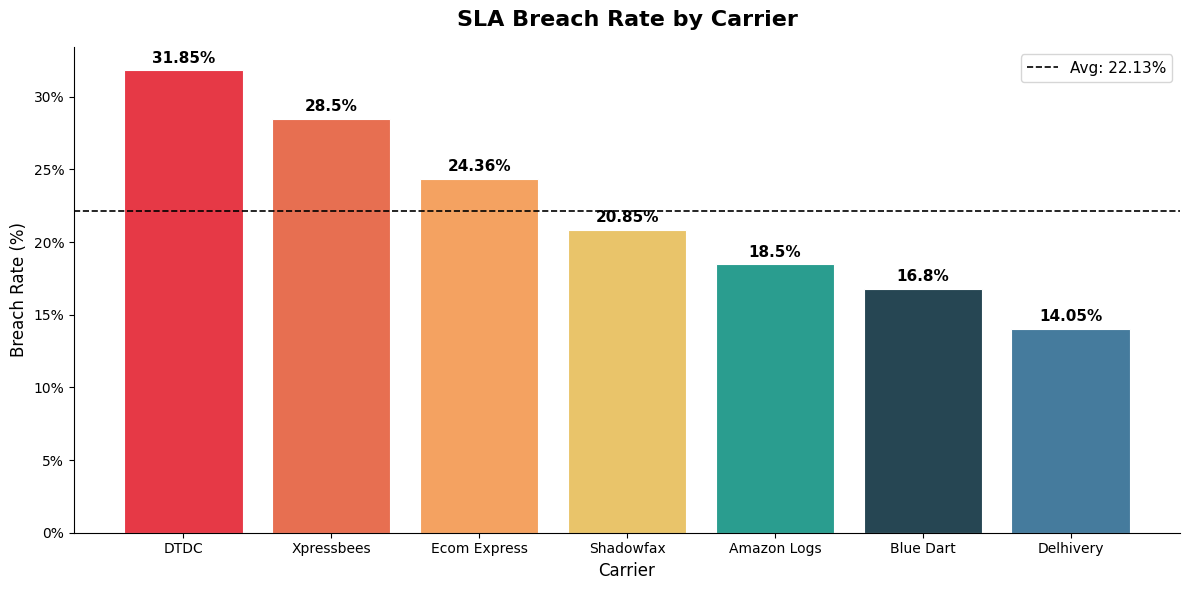

✅ Chart 1 saved!


In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(
    carrier['carrier'],
    carrier['breach_rate_pct'],
    color=PALETTE,
    edgecolor='white',
    linewidth=0.8
)

# Add value labels on top of bars
for bar, val in zip(bars, carrier['breach_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{val}%",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Reference line — overall average
avg = kpi['overall_breach_rate_pct'].values[0]
ax.axhline(avg, color='black', linestyle='--', linewidth=1.2, label=f'Avg: {avg}%')

ax.set_title("SLA Breach Rate by Carrier", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Carrier", fontsize=12)
ax.set_ylabel("Breach Rate (%)", fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../data/chart_breach_by_carrier.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

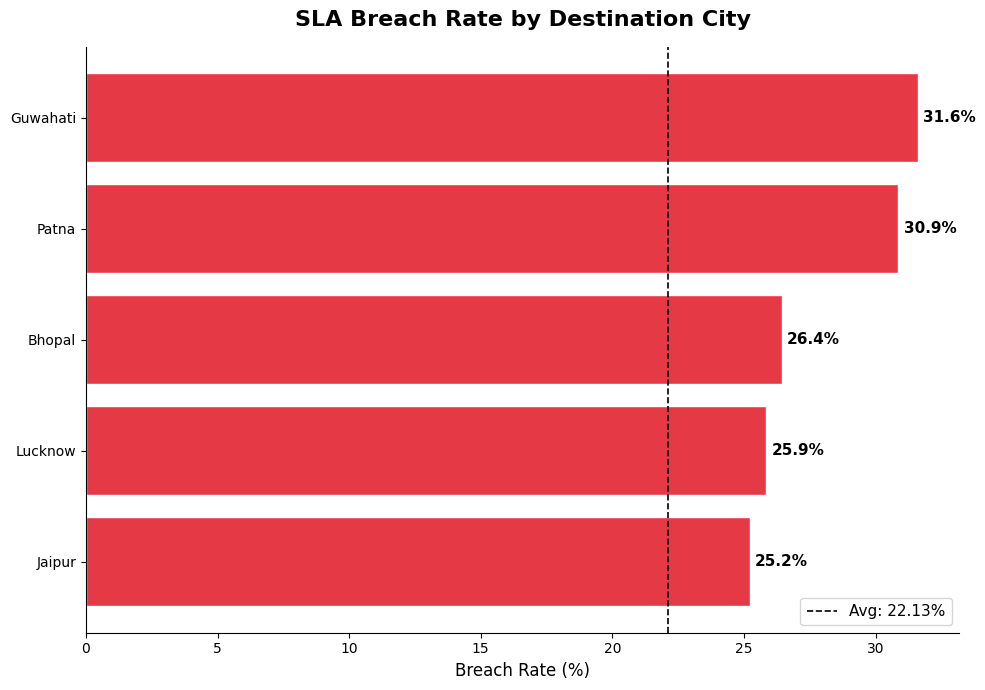

✅ Chart 2 saved!


In [4]:
# Aggregate by city (average across pincodes)
city_df = pincode.groupby('destination_city')['breach_rate_pct'].mean().reset_index()
city_df = city_df.sort_values('breach_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [BREACH_COLOR if x > avg else SAFE_COLOR for x in city_df['breach_rate_pct']]

bars = ax.barh(city_df['destination_city'],
               city_df['breach_rate_pct'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, city_df['breach_rate_pct']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%",
            va='center', fontsize=11, fontweight='bold')

ax.axvline(avg, color='black', linestyle='--', linewidth=1.2, label=f'Avg: {avg}%')
ax.set_title("SLA Breach Rate by Destination City", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Breach Rate (%)", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../data/chart_breach_by_city.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

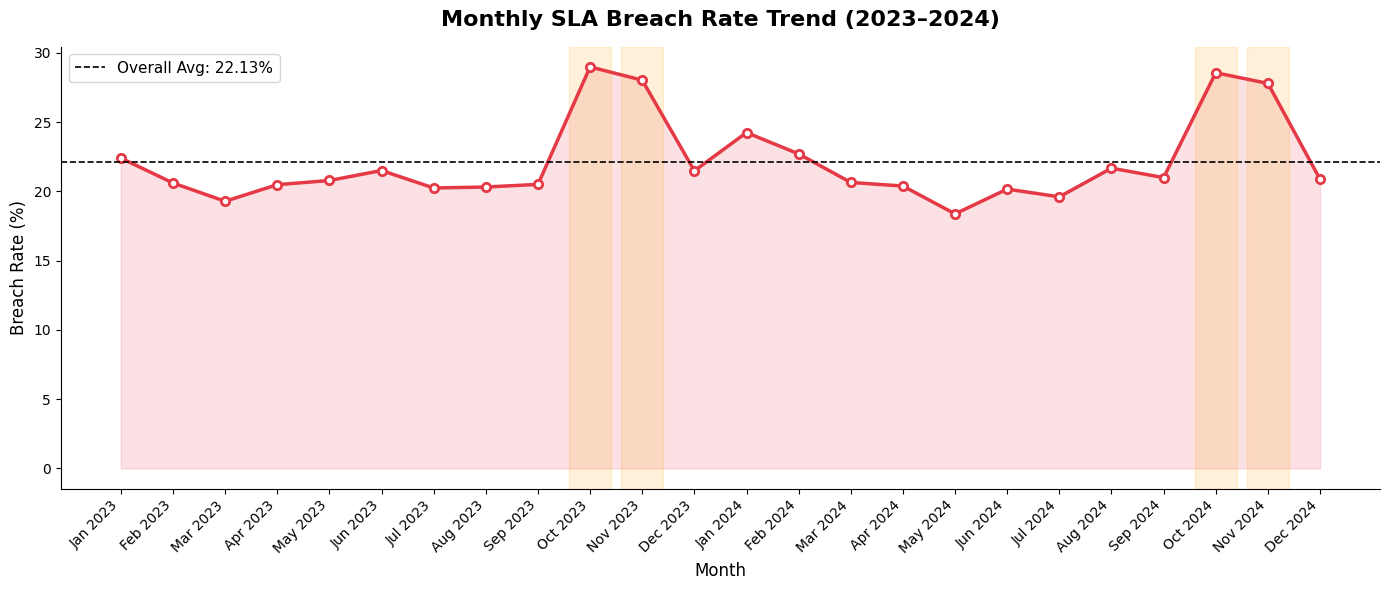

✅ Chart 3 saved!


In [5]:
# Sort months in calendar order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month['month'] = pd.Categorical(month['month'], categories=month_order, ordered=True)
month_sorted = month.sort_values(['year','month'])
month_sorted['label'] = month_sorted['month'].astype(str).str[:3] + " " + month_sorted['year'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(month_sorted['label'],
        month_sorted['breach_rate_pct'],
        color=BREACH_COLOR, linewidth=2.5,
        marker='o', markersize=6, markerfacecolor='white',
        markeredgecolor=BREACH_COLOR, markeredgewidth=2)

ax.fill_between(range(len(month_sorted)),
                month_sorted['breach_rate_pct'],
                alpha=0.15, color=BREACH_COLOR)

# Highlight festive months
for i, row in month_sorted.reset_index().iterrows():
    if row['month'] in ['October', 'November']:
        ax.axvspan(i-0.4, i+0.4, alpha=0.15, color='orange', label='Festive Season' if i==0 else "")

ax.axhline(avg, color='black', linestyle='--', linewidth=1.2, label=f'Overall Avg: {avg}%')
ax.set_title("Monthly SLA Breach Rate Trend (2023–2024)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Breach Rate (%)", fontsize=12)
plt.xticks(rotation=45, ha='right')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../data/chart_monthly_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

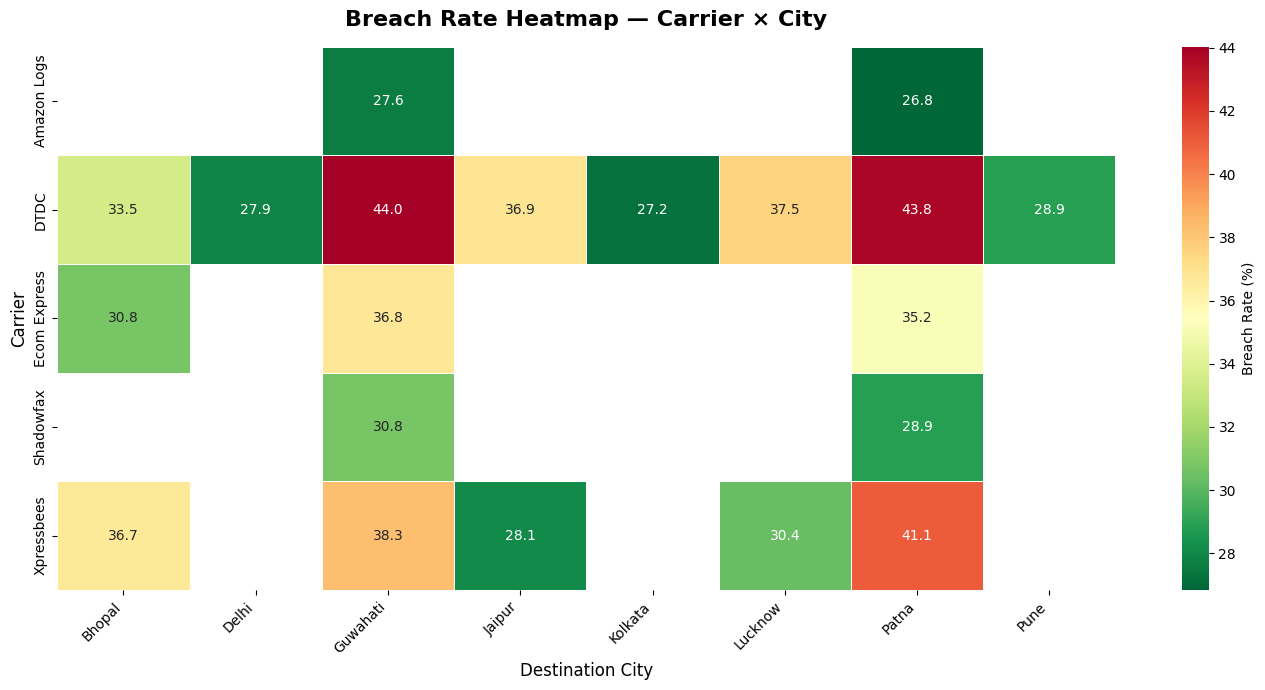

✅ Chart 4 saved!


In [6]:
# Pivot for heatmap
pivot = carrier_city.pivot(index='carrier',
                           columns='destination_city',
                           values='breach_rate_pct')

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(pivot,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn_r',      # Red = bad, Green = good
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Breach Rate (%)'})

ax.set_title("Breach Rate Heatmap — Carrier × City", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Destination City", fontsize=12)
ax.set_ylabel("Carrier", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../data/chart_heatmap_carrier_city.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

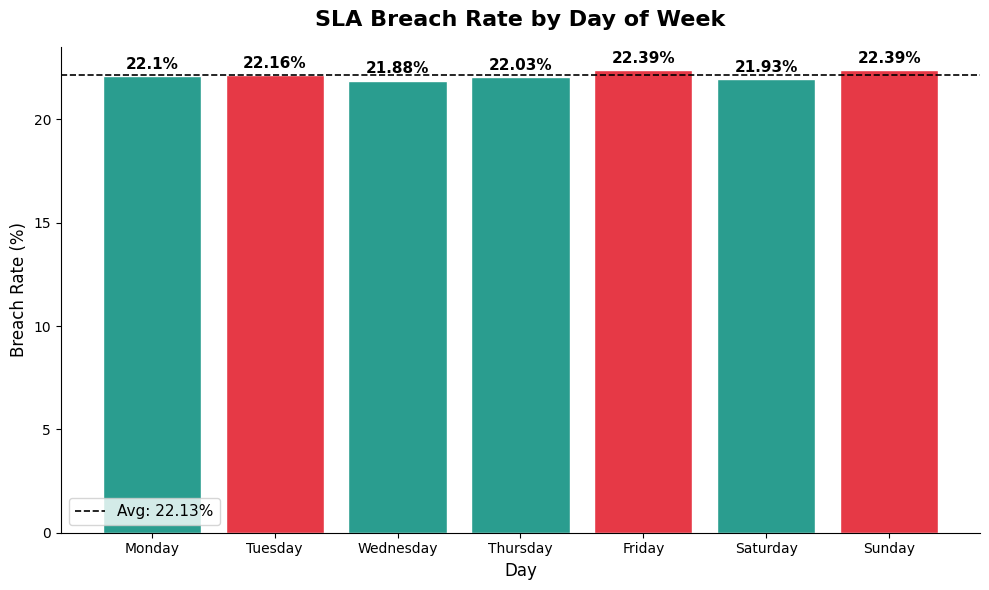

✅ Chart 5 saved!


In [7]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day['day_of_week'] = pd.Categorical(day['day_of_week'], categories=day_order, ordered=True)
day_sorted = day.sort_values('day_of_week')

fig, ax = plt.subplots(figsize=(10, 6))

colors = [BREACH_COLOR if x > avg else SAFE_COLOR for x in day_sorted['breach_rate_pct']]
bars = ax.bar(day_sorted['day_of_week'], day_sorted['breach_rate_pct'],
              color=colors, edgecolor='white')

for bar, val in zip(bars, day_sorted['breach_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f"{val}%",
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.axhline(avg, color='black', linestyle='--', linewidth=1.2, label=f'Avg: {avg}%')
ax.set_title("SLA Breach Rate by Day of Week", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Day", fontsize=12)
ax.set_ylabel("Breach Rate (%)", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("../data/chart_breach_by_day.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

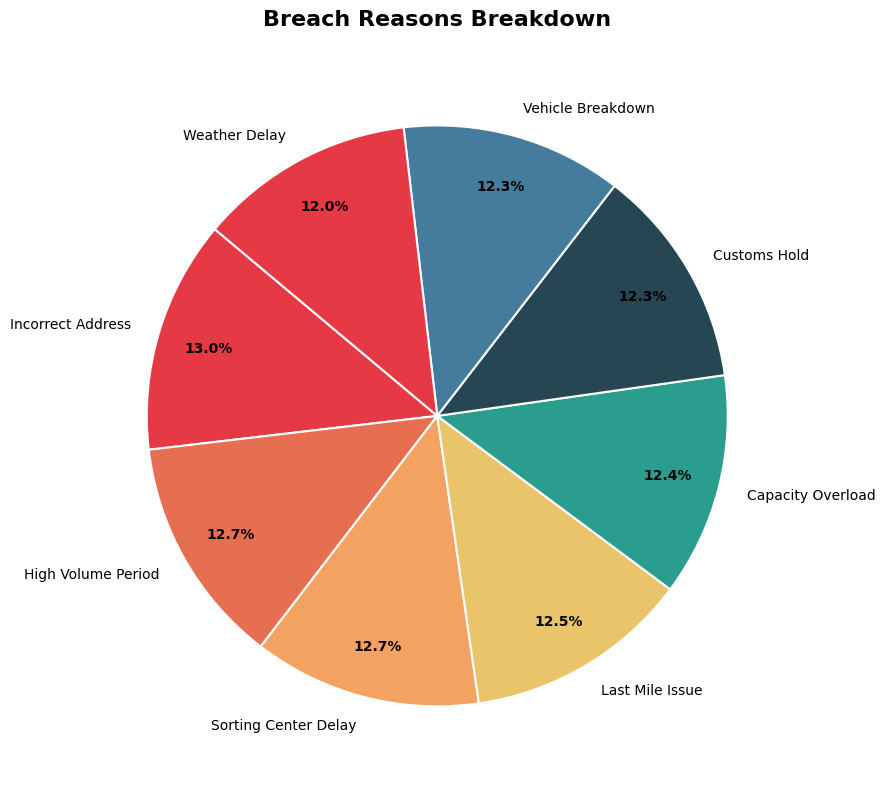

✅ Chart 6 saved!


In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    reason['occurrences'],
    labels=reason['breach_reason'],
    autopct='%1.1f%%',
    colors=PALETTE,
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

for text in autotexts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

ax.set_title("Breach Reasons Breakdown", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../data/chart_breach_reasons.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

In [9]:
print("""
╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — SUPPLY CHAIN ANALYSIS            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 Overall breach rate: 22.1%                          ║
║                                                          ║
║  🚚 Worst carrier  : DTDC (31.9%)                       ║
║  ✅ Best carrier   : Delhivery (14.1%)                  ║
║                                                          ║
║  📍 Worst city     : Guwahati (31.6%)                   ║
║  ✅ Best city      : Mumbai (16.5%)                     ║
║                                                          ║
║  📅 Festive spike  : Oct/Nov breach rate jumps ~40%     ║
║                                                          ║
║  ⚠️  Root cause    : Capacity Overload + Last Mile      ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         KEY FINDINGS — SUPPLY CHAIN ANALYSIS            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 Overall breach rate: 22.1%                          ║
║                                                          ║
║  🚚 Worst carrier  : DTDC (31.9%)                       ║
║  ✅ Best carrier   : Delhivery (14.1%)                  ║
║                                                          ║
║  📍 Worst city     : Guwahati (31.6%)                   ║
║  ✅ Best city      : Mumbai (16.5%)                     ║
║                                                          ║
║  📅 Festive spike  : Oct/Nov breach rate jumps ~40%     ║
║                                                          ║
║  ⚠️  Root cause    : Capacity Overload + Last Mile      ║
║                                                          ║
╚════════════════════════════════════